# StdMultiEditor/"Standard Display" 101

This notebook is the **hello world** for the StdMultiEditor specific rendering API. You will learn how to:

- Get a handle to the workbench editor "Standard Display" (axial / sagittal / coronal / 3D)
- Read each window's slice bounds, selected slice, and camera state
- Drive the slice navigator and the camera programmatically
- Capture per-window screenshots and render them inline

**Prerequisites:** A running MITK Workbench instance with the REST API enabled
at `http://localhost:8080`.


## 1. Connect

`mw.connect()` is lazy -- the first network call is `wb.ping()` below. If the
Workbench is not reachable we exit early so the rest of the notebook does not
produce confusing failures.


In [1]:
import mitk_workbench_remote as mw

wb = mw.connect("http://localhost:8080")
if not wb.ping():
    raise SystemExit("Workbench unreachable at http://localhost:8080. Start it and re-run.")
print(f"Connected to {wb.info.name} (MITK {wb.info.mitk_version}, API {wb.info.api_version}).")


Connected to MITK Workbench REST API (MITK 2025.12.99-51d3c136, API v1).


## 2. Load a phantom

The `mitk_workbench_remote.examples.phantoms` module ships small synthetic
volumes for the example notebooks. We use a CT-like body-and-tumor phantom so
the editor has something concrete to display.


In [2]:
from mitk_workbench_remote.examples import phantoms

ct = phantoms.make_body_with_tumor("ct")
node = wb.show(ct, name="CT phantom")
print(f"Loaded {node}")
print(f"  shape   = {ct.shape}")
print(f"  spacing = {ct.spacing}")


Loaded <DataNode 'CT phantom' (Image) @ /CT phantom uid=node_5>
  shape   = (32, 96, 96)
  spacing = (1.0, 1.0, 2.5)


## 3. The `StdMultiEditor` handle

`wb.std_multi` returns a stateless wrapper around the StdMultiWidget editor.
Every state read goes to the network -- the wrapper holds only the transport.

`get_info()` gives you the editor's plugin id and current window list.


In [3]:
editor = wb.std_multi
info = editor.get_info()
print(f"alias    = {info.alias}")
print(f"plugin   = {info.plugin_id}")
print(f"active   = {info.active}")
print(f"windows  = {info.windows}")


alias    = stdmulti
plugin   = org.mitk.editors.stdmultiwidget
active   = True
windows  = ('stdmulti.widget1', 'stdmulti.widget0', 'stdmulti.widget3', 'stdmulti.widget2')


## 4. The four named windows

The StdMultiWidget always exposes the same four slots: axial, sagittal,
coronal, and a 3D window. The editor exposes them as named properties for
convenience. Each one is a `RenderWindow` you can drive independently.

Note: `three_d` is the spelled-out alias of the window whose id is `"3d"` --
`"3d"` is not a valid Python identifier so the property cannot be called that.


In [4]:
named = {
    "axial":    editor.axial,
    "sagittal": editor.sagittal,
    "coronal":  editor.coronal,
    "3d":       editor.three_d,
}
for label, win in named.items():
    print(f"{label:9s} id={win.id!r:12s} kind={win.kind}")


axial     id='axial'      kind=2d
sagittal  id='sagittal'   kind=2d
coronal   id='coronal'    kind=2d
3d        id='3d'         kind=3d


## 5. Slice navigation

Every 2D window has a slice navigator. `get_selected_slice()` returns the
current step index, the world-space position on the live slice plane, and the
navigator's bounds.

We jump the axial window to the middle of its range. Because each modality
has its own bounds, "middle" is computed from the live `SliceBounds`, not
hard-coded.


In [7]:
ax = editor.axial
state = ax.get_selected_slice()
print(f"current step = {state.step} / {state.bounds.steps}")
print(f"position     = {state.position}")
print(f"min_position = {state.bounds.min_position}")
print(f"max_position = {state.bounds.max_position}")

middle = state.bounds.steps // 2
ax.set_selected_slice(middle)
print(f"-> moved axial to step {middle}")


current step = 16 / 32
position     = (47.5, 47.5, 36.25)
min_position = (-0.5, -0.5, -1.25)
max_position = (95.5, 95.5, 78.75)
-> moved axial to step 16


## 6. Camera

`get_camera()` returns the current camera state. For 2D windows the relevant
zoom field is `parallel_scale` (smaller = more zoomed in). For the 3D window
the relevant field is `perspective_angle`.

You can either build a `Camera` value and pass it to `set_camera`, or pass
keyword fields directly. Both are equivalent.


In [8]:
cam = ax.get_camera()
print(f"position       = {cam.position}")
print(f"focal_point    = {cam.focal_point}")
print(f"parallel_scale = {cam.parallel_scale}")

# Zoom in by halving parallel_scale.
ax.set_camera(parallel_scale=cam.parallel_scale * 0.5)
print(f"-> zoomed axial to parallel_scale = {ax.get_camera().parallel_scale}")


position       = (47.5, 47.5, -899962.5)
focal_point    = (47.5, 47.5, 37.5)
parallel_scale = 35.705400981996725
-> zoomed axial to parallel_scale = 17.852700490998362


## 7. Per-window screenshots

`RenderWindow.screenshot()` returns raw PNG bytes from the live render
surface. We display all four windows as a single matplotlib figure -- handy
for previewing in the notebook without opening the workbench window.


-- axial --


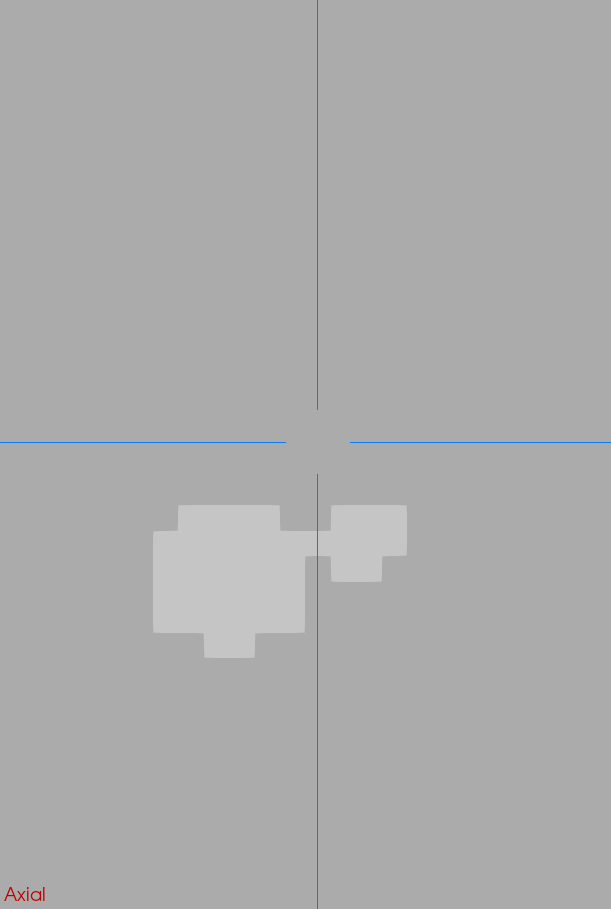

-- sagittal --


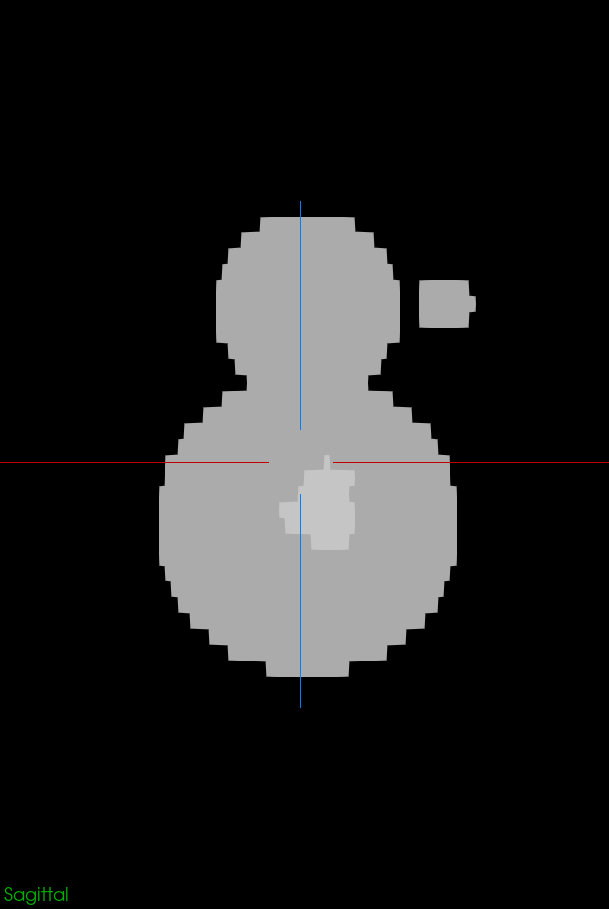

-- coronal --


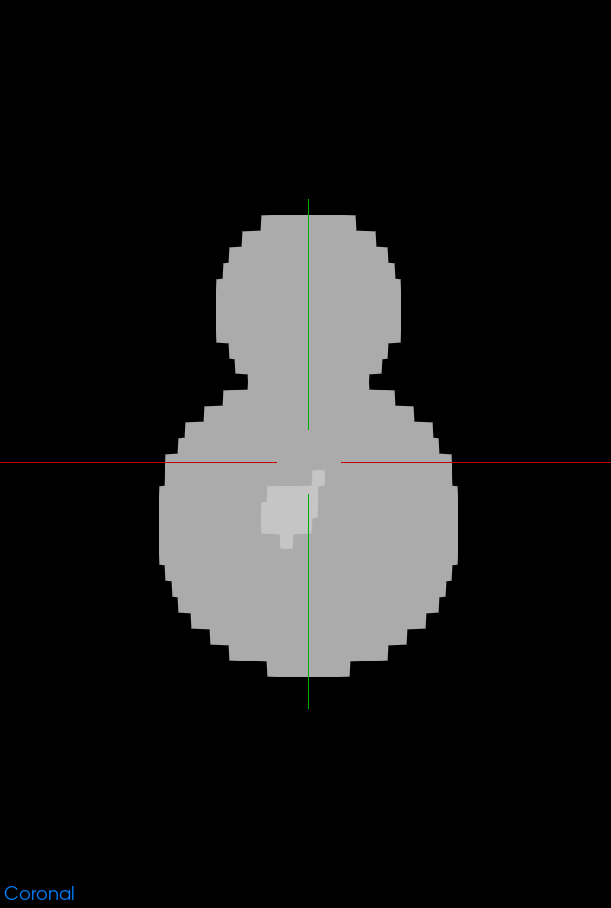

-- 3d --


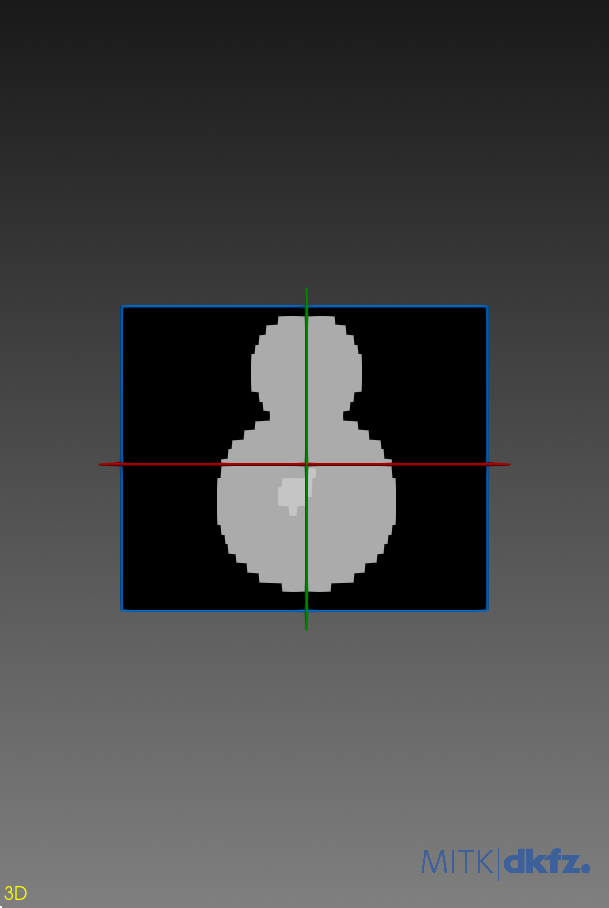

In [9]:
from IPython.display import Image as IPyImage, display

for label, win in named.items():
    print(f"-- {label} --")
    display(IPyImage(data=win.screenshot(), format="png"))


## 8. Recap and clean up

Endpoints exercised in this notebook:

- `GET /rendering/editors/stdmulti` -- editor info
- `GET /rendering/editors/stdmulti/windows/{id}` -- per-window summary (via `kind`)
- `GET/PUT /rendering/editors/stdmulti/windows/{id}/selected-slice`
- `GET/PUT /rendering/editors/stdmulti/windows/{id}/camera`
- `GET /rendering/editors/stdmulti/windows/{id}/screenshot`

Next stop: notebook 07 introduces the MxN multi-widget editor, which lets you
build arbitrary grids of synchronised render windows from Python.


In [20]:
node.remove()
print("Removed", node.uid)


Removed node_1
